# SHAP Analysis

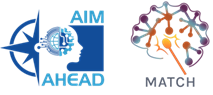

**Objective**

Obtain global and local interpretability plots (e.g., beeswarm, violin, heatmap, waterfall) using the SHAP Python package on the logistic regression model developed in the previous lesson



**Acknowledgements** <br>
aiMATCH Hands-on Workshop Series: Predictive modeling using healthcare data. NIH AIM AHEAD DICB Program <br>
Principal Investigator: Amina Qutub, Ph.D., University of Texas at San Antonio<br>
Workshop Presenter and Code Author: Mignon Dumanjog, M.S., University of Texas at San Antonio<br>

# Import packages & data

You can either load the data from Kaggle (through an API token which can be obtained from your Kaggle settings page), or from local files by uploading *train.csv*, *test.csv*, and *solution.csv* from the [aiMATCH GitHub page.](https://github.com/qutublab/aiMATCH/releases/tag/Predictive-modeling-workshop)<br>Run the cell corresponding to your chosen method.

In [ ]:
import numpy as np
import pandas as pd
import os

*From Kaggle*

In [ ]:
# NEVER SHARE YOUR API TOKEN PUBLICLY.
# Tip: Store your API token as a Secret in Google Colab.
# If running locally, do not commit your .env file or it will expose secrets
# that will allow others to control access to your various AI and authentication provider accounts.
import kagglehub
kagglehub.login()

aimatch_workshop_predicting_health_outcomes_path = kagglehub.competition_download('aimatch-workshop-predicting-health-outcomes')

print('Data source import complete.')

train_df = pd.read_csv(os.path.join(aimatch_workshop_predicting_health_outcomes_path, 'Train.csv'))
test_df = pd.read_csv(os.path.join(aimatch_workshop_predicting_health_outcomes_path, 'Test.csv'))
solution_df = pd.read_csv(os.path.join(aimatch_workshop_predicting_health_outcomes_path, 'Solution.csv'))


100%|██████████| 5.13k/5.13k [00:00<00:00, 8.43MB/s]

Extracting files...
Data source import complete.


*From files*

In [ ]:
train_df = pd.read_csv('/path/Train.csv') # change to actual path
test_df = pd.read_csv('/path/Test.csv') # change to actual path
solution_df = test_df = pd.read_csv('/path/Solution.csv') # change to actual path

# Start with our trained logistic regressor from the previous lesson.



In [ ]:
X_train = train_df.iloc[:,1:-1]
y_train = train_df.iloc[:,-1]
y_train = y_train.replace({'CR/CRI': 1, 'NR': 0}).astype(int)
X_test = test_df

def id_column_type(df):
    numeric_columns = []
    text_columns = []
    for column_name in df.columns:

        if df[column_name].dtype in['int64','float64']:
            numeric_columns.append(df[column_name].name)
        else:
            text_columns.append(df[column_name].name)
    return numeric_columns, text_columns

numeric_features, categorical_features = id_column_type(X_train)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy = 'median')), # also try 'mean', 'most_frequent', etc.
        ("scaler", StandardScaler())
    ]
)

Xt_num = numeric_transformer.fit_transform(X_train[numeric_features])
Xt_num_df = pd.DataFrame(Xt_num, columns=numeric_features)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

Xt_cat = categorical_transformer.fit_transform(X_train[categorical_features])

ohe = categorical_transformer.named_steps["onehot"]

feature_names = ohe.get_feature_names_out(categorical_features)

Xt_cat_df = pd.DataFrame(
    Xt_cat.toarray(),
    columns=feature_names
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

from sklearn.linear_model import LogisticRegression
lr = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
        # Try: ("classifier", LogisticRegression(l1_ratio = 0.1, solver='saga', max_iter=1000))
    ]
)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_proba = lr.predict_proba(X_test)[:, 1]
accuracy = (y_pred == solution_df['Response Simple']).mean()
print(f"Accuracy: {accuracy}")

print(lr.named_steps)

Accuracy: 0.7941176470588235
{'preprocess': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age.Dx', 'Weight.kg', 'BMI', 'HCT',
                                  'Protein A', 'Protein B', 'Protein C']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['FAB.(Assigned)', 'Age.subgroup',
                                  'Dysplasia'])]), 'classifier': LogisticRegression(max_iter=1000)}


/tmp/ipykernel_415/1887885904.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({'CR/CRI': 1, 'NR': 0}).astype(int)


# SHAP Analysis

In [ ]:
import shap

X_train_t = lr.named_steps["preprocess"].transform(X_train)
X_test_t  = lr.named_steps["preprocess"].transform(X_test)
feature_names = lr.named_steps["preprocess"].get_feature_names_out()
X_train_tdf = pd.DataFrame(X_train_t, columns=feature_names)
X_test_tdf = pd.DataFrame(X_test_t, columns=feature_names)
clf = lr.named_steps["classifier"]

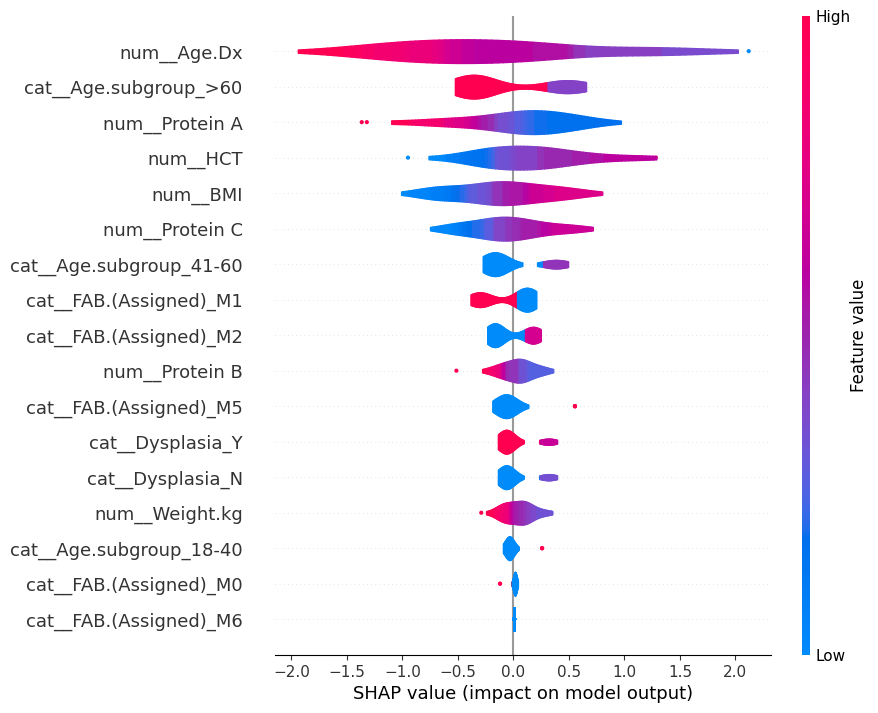

In [ ]:
explainer = shap.Explainer(clf, X_train_t)
shap_values = explainer(X_test_tdf)
shap.plots.violin(shap_values)

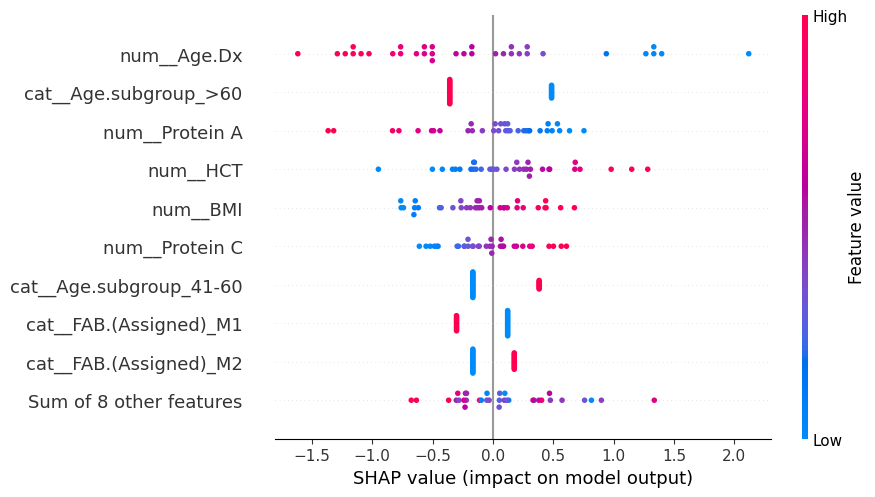

In [ ]:
shap.plots.beeswarm(shap_values)

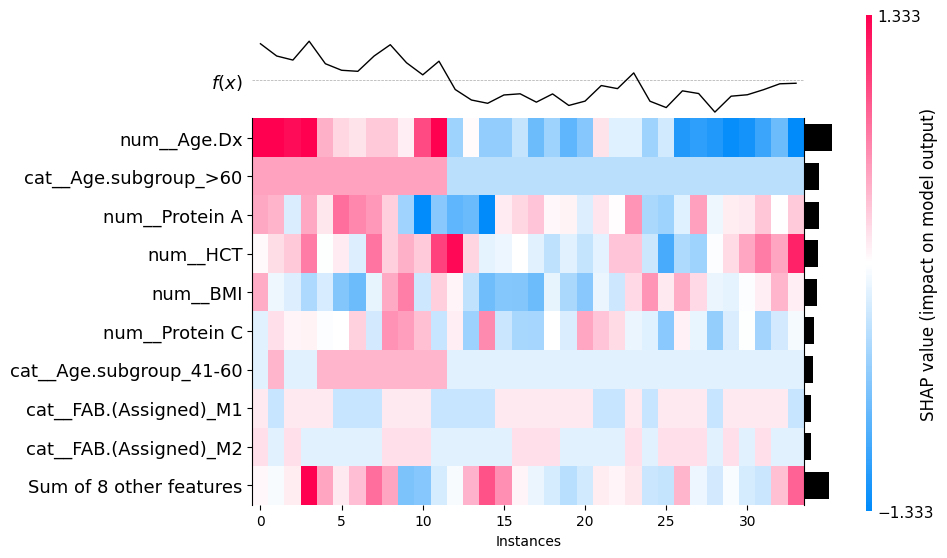

<Axes: xlabel='Instances'>

In [ ]:
shap.plots.heatmap(shap_values)

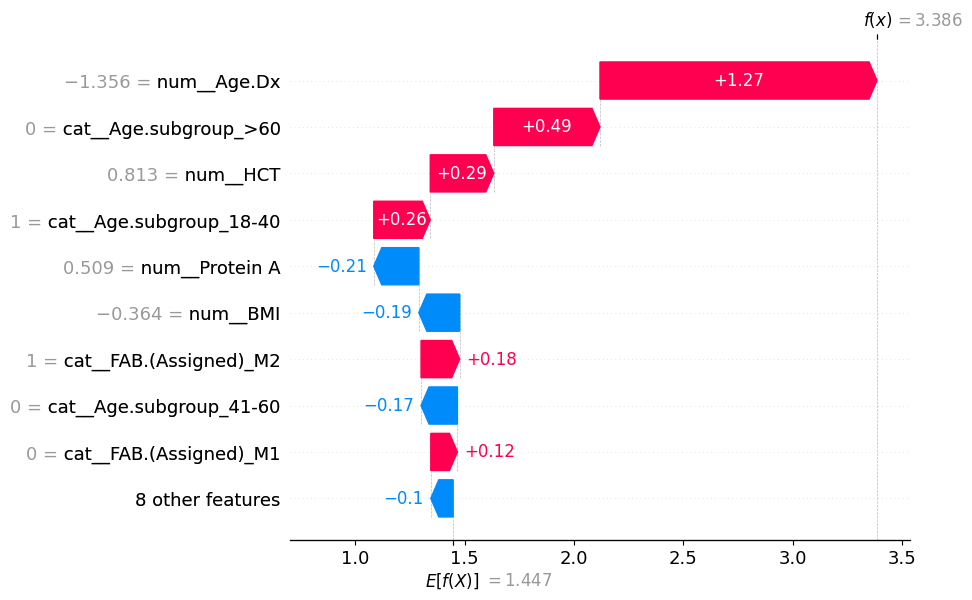

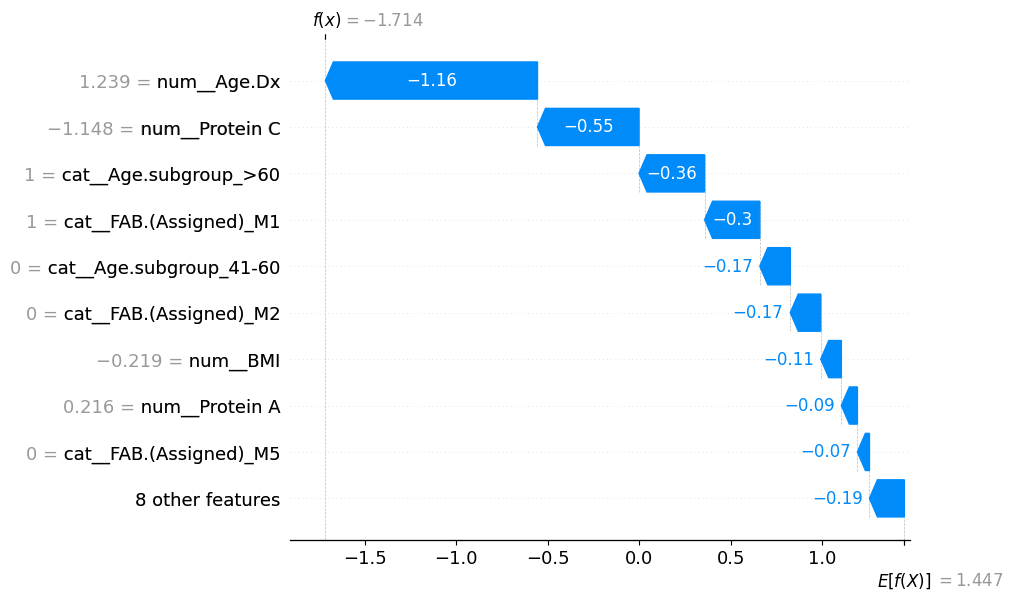

In [ ]:
shap.plots.waterfall(shap_values[1])
shap.plots.waterfall(shap_values[5]) # you can try different patient indices